In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.autolayout': True})

In [3]:
df = pd.read_csv('data/final_house_data.csv')

In [4]:
df['building_age_num'] = df['building_age'].apply(lambda x: 0 if 'Sıfır' in str(x) else int(str(x).split(' ')[0]) if 'Yaşında' in str(x) else 0)
df['total_rooms'] = df['room_count'].apply(lambda x: sum([int(p.strip()) for p in str(x).split('+')]) if '+' in str(x) else 1)

In [5]:
df_eda = df[(df['price'] < 50000000) & (df['gross_sqm'] < 500)].copy()

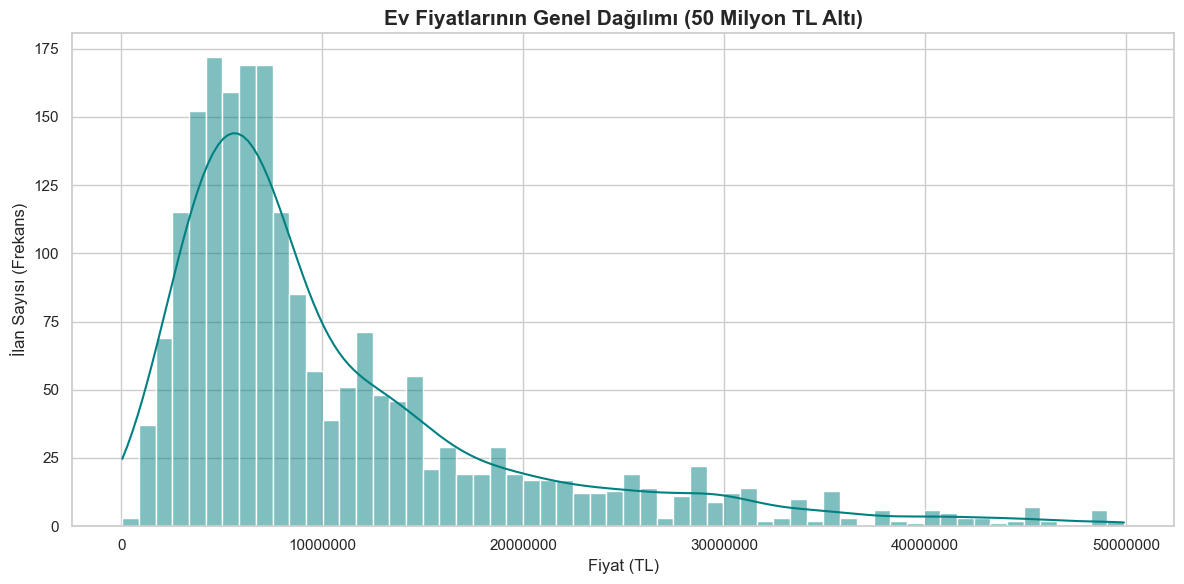

In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(df_eda['price'], bins=60, kde=True, color='teal')
plt.title('Ev Fiyatlarının Genel Dağılımı (50 Milyon TL Altı)', fontsize=15, fontweight='bold')
plt.xlabel('Fiyat (TL)', fontsize=12)
plt.ylabel('İlan Sayısı (Frekans)', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Bilimsel gösterimi (1e7) kapatır
plt.show()

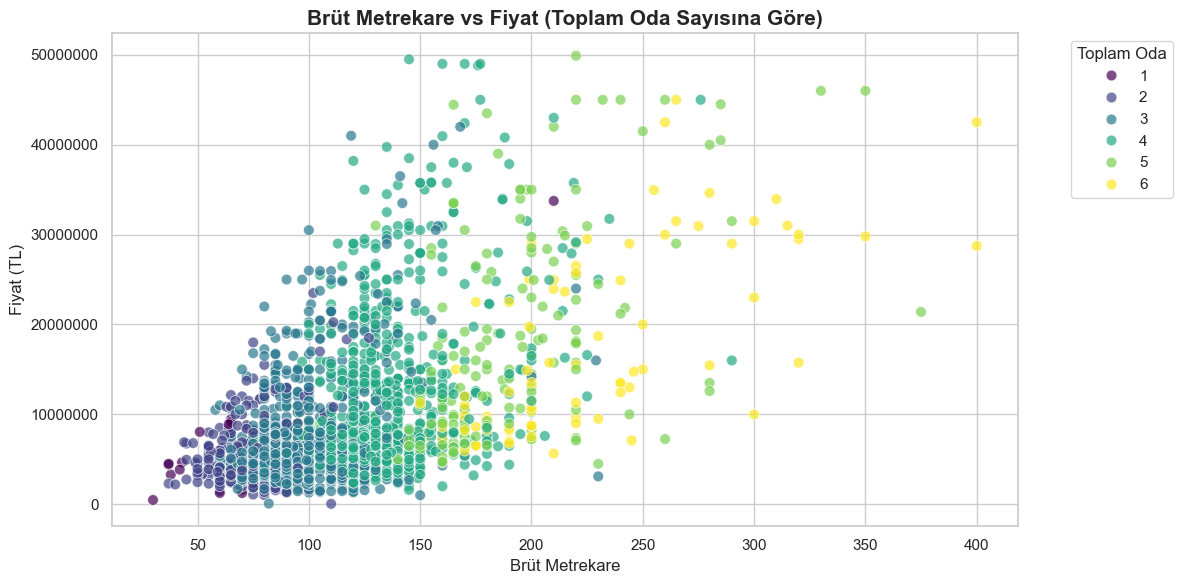

In [7]:
plt.figure(figsize=(12, 6))
df_scatter = df_eda[df_eda['total_rooms'].between(1, 6)]
sns.scatterplot(x='gross_sqm', y='price', hue='total_rooms', palette='viridis', data=df_scatter, alpha=0.7, s=60)
plt.title('Brüt Metrekare vs Fiyat (Toplam Oda Sayısına Göre)', fontsize=15, fontweight='bold')
plt.xlabel('Brüt Metrekare', fontsize=12)
plt.ylabel('Fiyat (TL)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.legend(title='Toplam Oda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_19924\3631106224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_expensive.values, y=top_10_expensive.index, palette='magma')


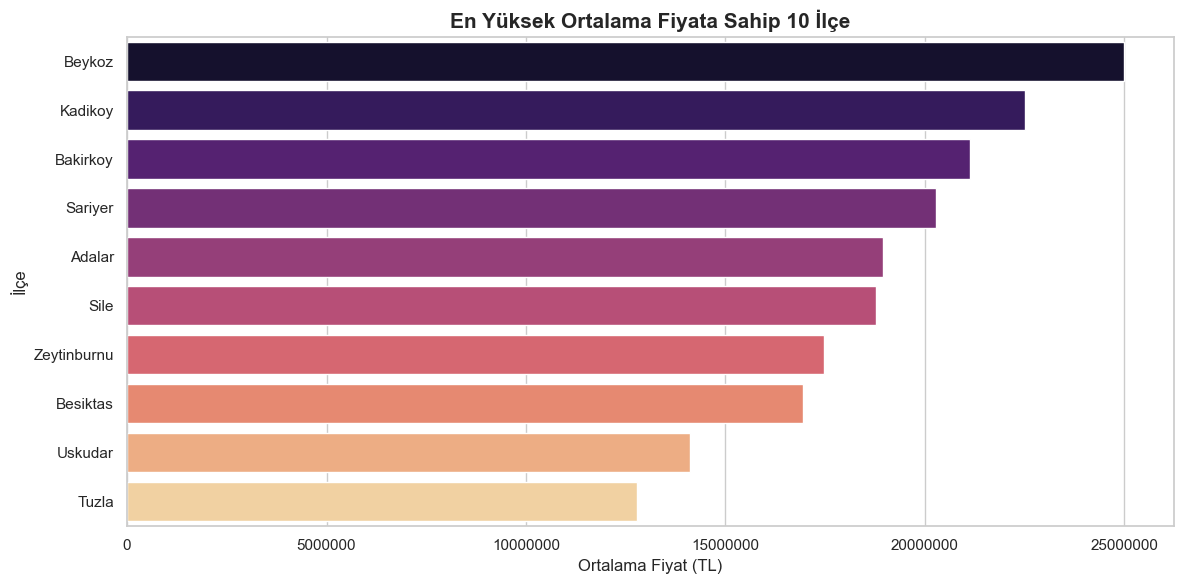

In [8]:
plt.figure(figsize=(12, 6))
top_10_expensive = df_eda.groupby('district_name')['price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_10_expensive.values, y=top_10_expensive.index, palette='magma')
plt.title('En Yüksek Ortalama Fiyata Sahip 10 İlçe', fontsize=15, fontweight='bold')
plt.xlabel('Ortalama Fiyat (TL)', fontsize=12)
plt.ylabel('İlçe', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_19924\2415798978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_count.values, y=top_10_count.index, palette='crest')


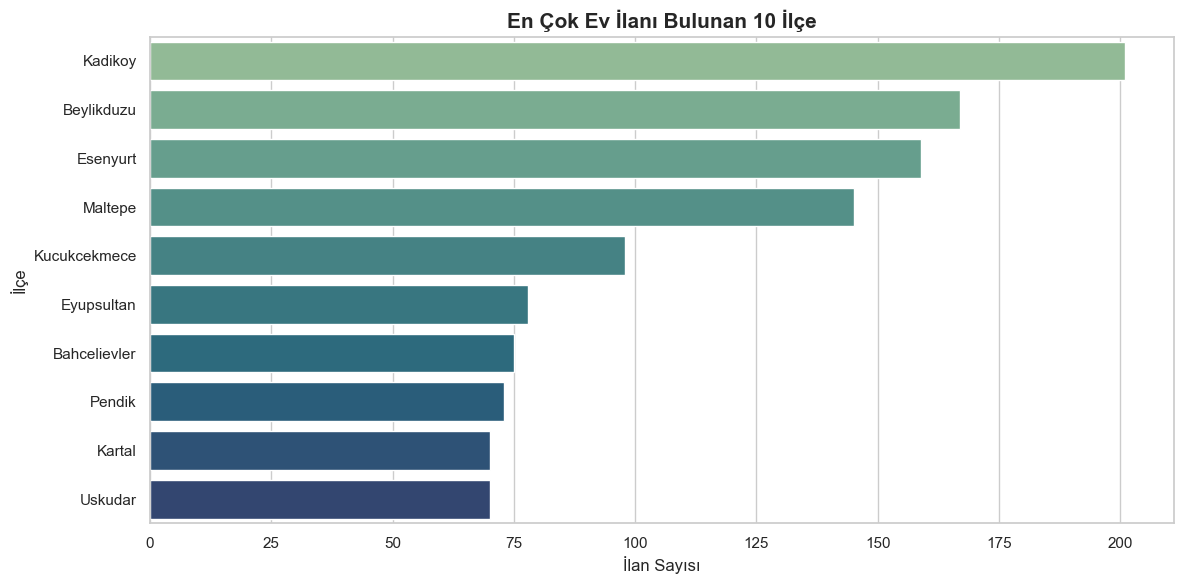

In [9]:
plt.figure(figsize=(12, 6))
top_10_count = df_eda['district_name'].value_counts().head(10)
sns.barplot(x=top_10_count.values, y=top_10_count.index, palette='crest')
plt.title('En Çok Ev İlanı Bulunan 10 İlçe', fontsize=15, fontweight='bold')
plt.xlabel('İlan Sayısı', fontsize=12)
plt.ylabel('İlçe', fontsize=12)
plt.show()

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_19924\645934642.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price', y='heating_type', data=df_heating, palette='Set2')


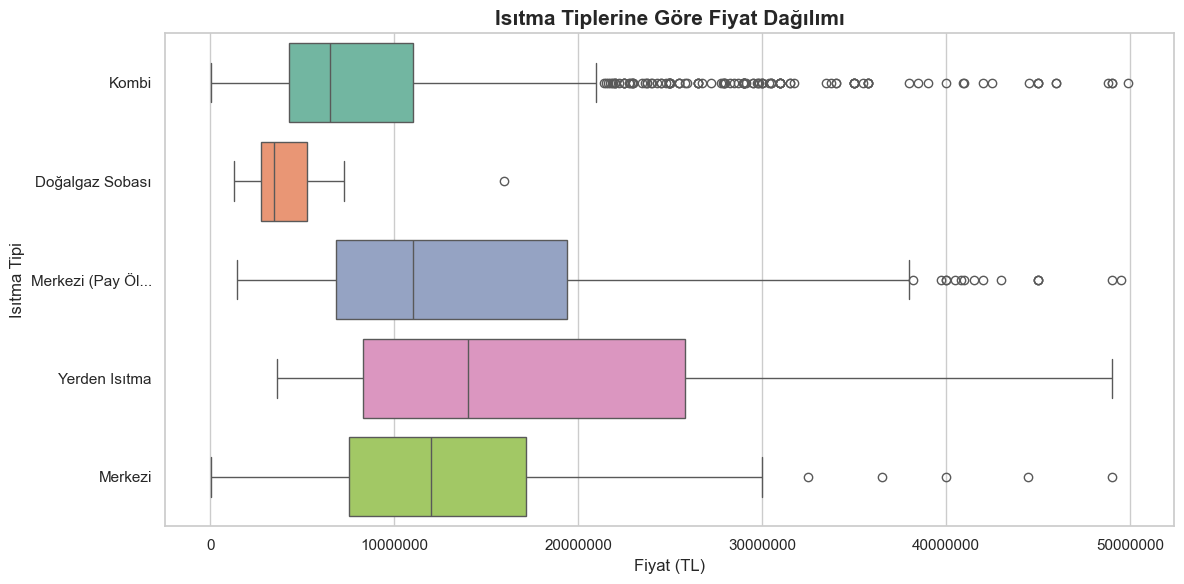

In [11]:
plt.figure(figsize=(12, 6))
top_heating = df_eda['heating_type'].value_counts().head(5).index
df_heating = df_eda[df_eda['heating_type'].isin(top_heating)]
sns.boxplot(x='price', y='heating_type', data=df_heating, palette='Set2')
plt.title('Isıtma Tiplerine Göre Fiyat Dağılımı', fontsize=15, fontweight='bold')
plt.xlabel('Fiyat (TL)', fontsize=12)
plt.ylabel('Isıtma Tipi', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

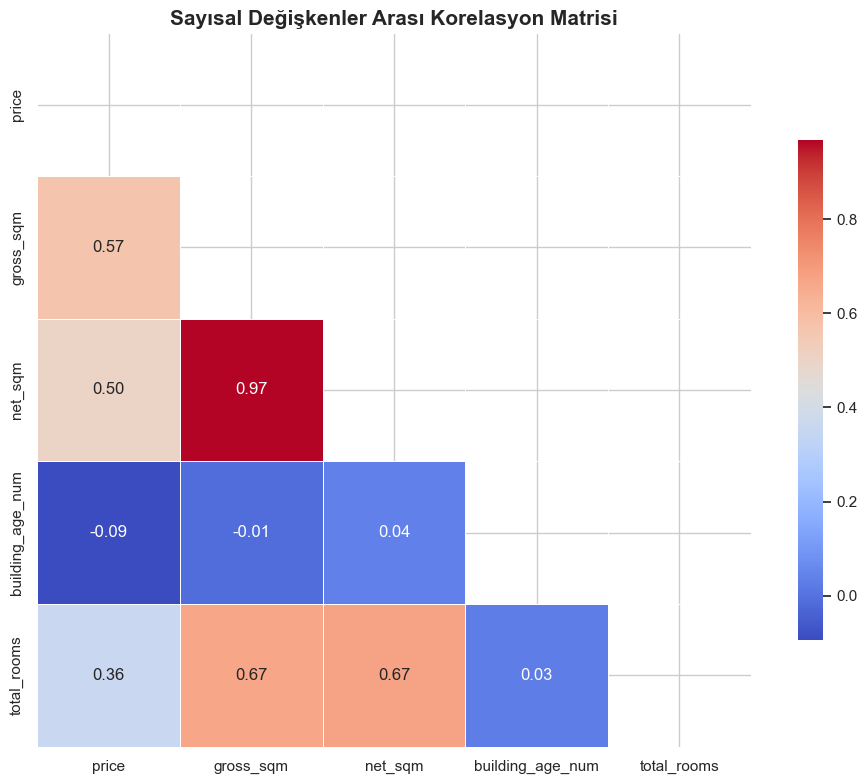

In [12]:
plt.figure(figsize=(10, 8))
numeric_cols = df_eda.select_dtypes(include=[np.number])
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .7})
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi', fontsize=15, fontweight='bold')
plt.show()

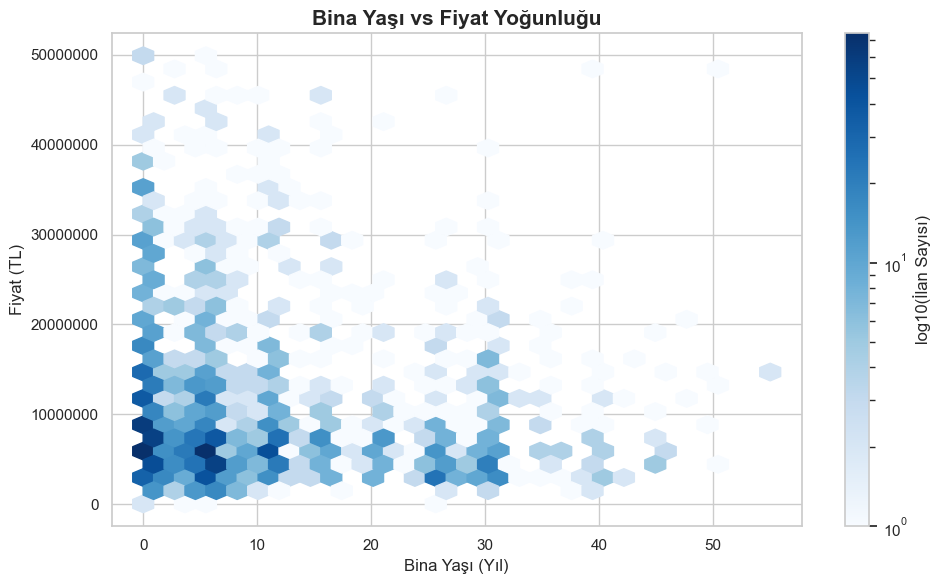

In [13]:
plt.figure(figsize=(10, 6))
plt.hexbin(df_eda['building_age_num'], df_eda['price'], gridsize=30, cmap='Blues', bins='log')
plt.title('Bina Yaşı vs Fiyat Yoğunluğu', fontsize=15, fontweight='bold')
plt.xlabel('Bina Yaşı (Yıl)')
plt.ylabel('Fiyat (TL)')
plt.ticklabel_format(style='plain', axis='y')
cb = plt.colorbar(label='log10(İlan Sayısı)')
plt.show()